## Energy-Model Hybrid Execution with AMD Ryzen CPUs

This experiment conducts the hybrid simulation to include **energy and cost modeling**
while replacing the generic CPU model with **AMD Ryzen–based CPUs**

This experiment is designed for ICPP 2026 conference.

In [1]:
# main.py

from HybridCloud import *

PRINTLOG = False
# Devices
ibm_strasbourg = IBM_Strasbourg(env=None, name="QPU-1", printlog = PRINTLOG)
ibm_brussels = IBM_Brussels(env=None, name="QPU-2", printlog = PRINTLOG)
ibm_marrakesh = IBM_Marrakesh(env=None, name="QPU-3", printlog = PRINTLOG)
ibm_quebec = IBM_Quebec(env=None, name="QPU-4", printlog = PRINTLOG)
ibm_kyiv = IBM_Kyiv(env=None, name="QPU-5", printlog = PRINTLOG)
ryzen1 = AMDRyzen("CPU-1", env=None)
ryzen2 = AMDRyzen("CPU-2", env=None)
         
cost_config = {
  "energy": {
    "electricity_price_per_kwh": 0.18,
    "default_qpu_power_kw": 50.0,
    "qpu_power_kw": {"QPU-1": 50.0, "QPU-2": 50.0, "QPU-3":50.0, "QPU-4": 50.0, "QPU-5": 50.0},
    "cpu_power_kw": {"CPU-1": 5.0, "CPU-2": 6.0},
    "cpu_power_model": "affine",
    "default_cpu_idle_kw": 0.22,
    "default_cpu_peak_kw": 0.75,
    "default_cpu_capacity_units": 16,
    "debug_energy": False
  }
}


# Hybrid environment
sim_env = HybridCloudSimEnv(
    # qpu_devices = [ibm_strasbourg, ibm_brussels, ibm_marrakesh, ibm_quebec, ibm_kyiv],
    qpu_devices = [ibm_quebec, ibm_kyiv],
    cpu_devices = [ryzen1],
    broker_class = HybridBroker,
    job_feed_method = 'dispatcher',
    file_path = 'synth_job_batches/1200-batch-filtered-3.csv', 
    job_generation_model = None, 
    printlog = PRINTLOG, 
    cost_config=cost_config
)


print(f"cpu_power_model: {sim_env.cost_config['energy']['cpu_power_model']}")
print(f"default_cpu_idle_kw: {sim_env.cost_config['energy']['default_cpu_idle_kw']}")

sim_env.run()

cpu_power_model: affine
default_cpu_idle_kw: 0.22
2 QPU(s), 1 CPU(s)
0.00: SIMULATION STARTED
500 has been processed.
1000 has been processed.
3544.66: SIMULATION ENDED
Number of jobs processed: 1200

                 FINAL QUANTUM CLOUD SUMMARY                
Total Operational Lifetime : 3544.66 seconds
Global Cumulative QPU Util : 66.77%
Global Cumulative CPU Util : 22.99%
Global Cumulative Mem Util : 32.98%
------------------------------------------------------------
Individual Device Endstates:



In [2]:
from utility_functions import plot_cloud_utilization

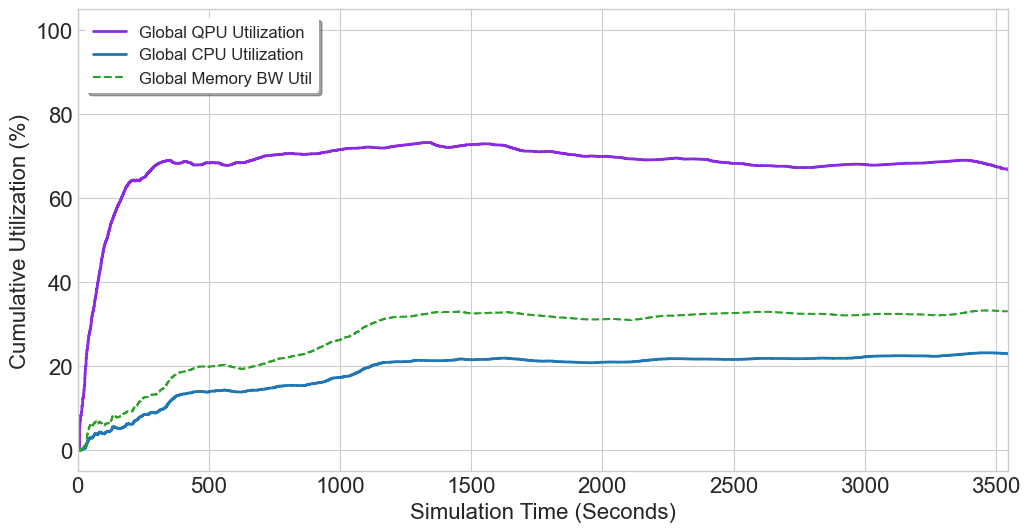

In [3]:
plot_cloud_utilization(sim_env.cloud_monitor)

In [4]:
rec = sim_env.job_records_manager.get_job_records()
for i in range(1, 2): 
    print("Job: ", i)
    print("QPU time (s):", rec[i]["qpu_time_s"])
    print("CPU time (s):", rec[i]["cpu_time_s"])
    print("Energy (kWh):", rec[i]["energy_total_kwh"])
    print("Cost ($):", rec[i]["cost_energy_total"])
    print("")

Job:  1
QPU time (s): 31.6889
CPU time (s): 0.185
Energy (kWh): 0.4404
Cost ($): 0.0793



### 1) Energy–cost decomposition (QPU vs CPU share)

From the generated results, we visualize. 

- Stacked bar of mean energy split (QPU vs CPU)
- Histogram of cost/job
- Prints summary stats (mean/median/p95)


=== Energy/Cost Summary ===
        number_of_jobs: 1200
   mean_energy_qpu_kwh: 0.607178
   mean_energy_cpu_kwh: 0.014130
 mean_energy_total_kwh: 0.621310
    std_energy_qpu_kwh: 0.315444
    std_energy_cpu_kwh: 0.087893
  std_energy_total_kwh: 0.338128
     mean_cost_per_job: 0.111835
      std_cost_per_job: 0.060863
   median_cost_per_job: 0.101200
      p95_cost_per_job: 0.216525
          mean_phi_qpu: 0.986576
          mean_phi_cpu: 0.013417
           std_phi_qpu: 0.060054
           std_phi_cpu: 0.060055
       mean_qpu_time_s: 43.716780
       mean_cpu_time_s: 10.176395
        std_qpu_time_s: 22.711976
        std_cpu_time_s: 63.283062
        p95_qpu_time_s: 84.591470
        p95_cpu_time_s: 34.044340
       mean_qpu_wait_s: 0.000000
       mean_cpu_wait_s: 0.000000
     mean_wait_total_s: 0.000000
        std_qpu_wait_s: 0.000000
        std_cpu_wait_s: 0.000000
      std_wait_total_s: 0.000000
      p95_wait_total_s: 0.000000
 mean_job_turnaround_s: 54.179632
  std_job_t

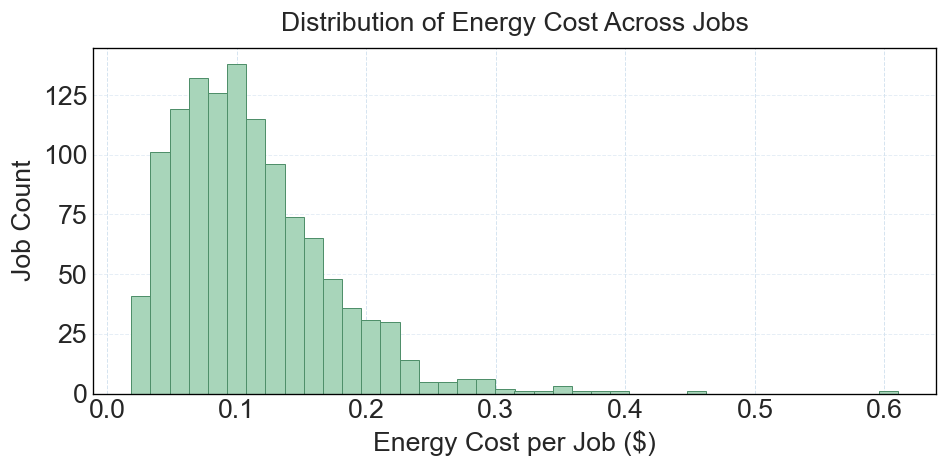

In [5]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility_functions import (
    set_elegant_style,
    build_job_energy_df,
    get_summary,
    plot_energy_split,
    plot_cost_distribution,
    plot_phi_qpu_distribution,
    plot_phi_cpu_distribution,
)

set_elegant_style()

# ---- Run after sim_env.run() ----
job_records = sim_env.job_records_manager.job_records
df = build_job_energy_df(job_records)

get_summary(df)
# plot_energy_split(df)
plot_cost_distribution(df)
# plot_phi_qpu_distribution(df)
# plot_phi_cpu_distribution(df)

In [6]:
import numpy as np
from utility_functions import energy_per_step_time_series

STEP = 10

In [7]:
from utility_functions import plot_energy_per_step

In [8]:
ts, qpu_e_step, cpu_e_step = energy_per_step_time_series(
    job_records=job_records,
    qpu_capacity_units=640,
    cpu_capacity_units=200,
    step=STEP,

    # power assumptions (example values)
    qpu_idle_w=100000.0,   # superconducting baseline
    qpu_peak_w=300000.0,   # baseline + active overhead
    cpu_idle_w=80.0,
    cpu_peak_w=360.0
)

### Mental model

The plot is instantaneous energy consumption per simulation step, reconstructed from execution traces.

NOTE: “superconducting QPU energy is baseline-dominated”

In [9]:
from utility_functions import plot_energy_per_step_dual_axis

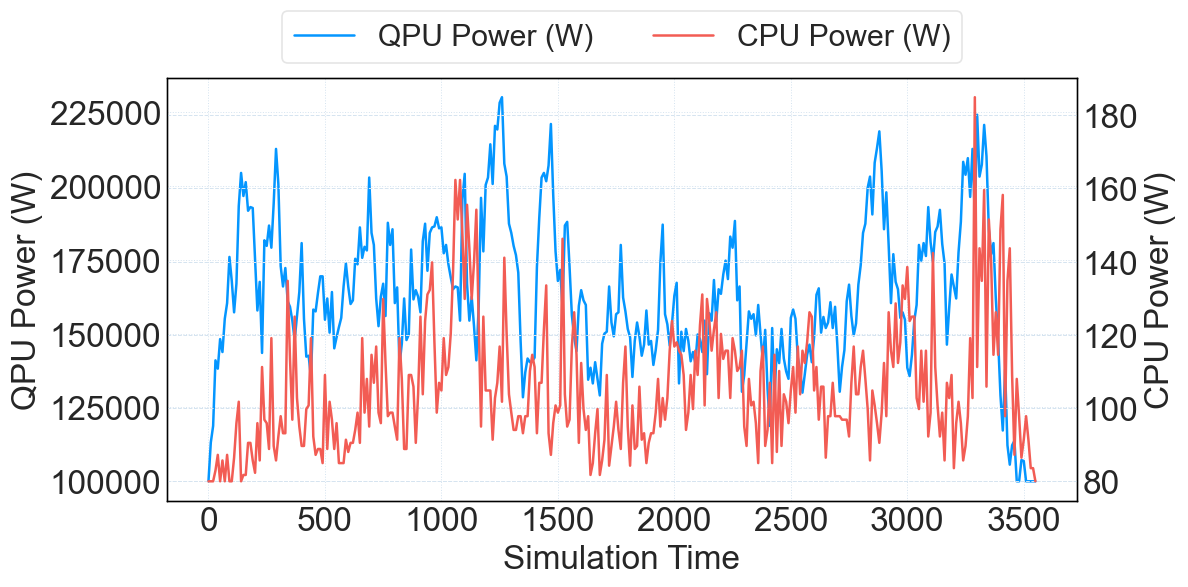

In [10]:
qpu_power_w = [e / STEP for e in qpu_e_step]
cpu_power_w = [e / STEP for e in cpu_e_step]

plot_energy_per_step_dual_axis(ts, qpu_power_w, cpu_power_w)

In [11]:
import numpy as np
np.mean(qpu_power_w)


np.float64(163301.43960674157)

In [12]:
np.mean(cpu_power_w)

np.float64(105.34952384441414)

In [ ]:
history = getattr(sim_env.cloud_monitor, "utilization_history", [])